Задание 8. Проверка гипотез

Инструкция:

Шаг 1.  Изучите материалы лекционных и практических занятий по темам раздела 4.

Шаг 2. Составьте и проверьте гипотезы о данных по предложенному датасету (Алгоритм выполнения представлен в практическом занятии по теме 4.4).

Шаг 3. Выполните анализ корреляции признаков  (Алгоритм выполнения представлен в практическом занятии по теме 4.4).

Шаг 4. Опубликуйте файл расширения ipynb на платформе Odin.

# Описание данных
Каждый клиент описывается следующим набором признаков:
- `Возраст`, `Среднемесячный расход`, `Средняя продолжительность разговоров`, `Звонков днем за месяц`, `Звонков вечером за месяц`, `Звонков ночью за месяц`, `Звонки в другие города`, `Звонки в другие страны`, `Доля звонков на стационарные телефоны`, `Количество SMS за месяц`, `Дата подключения тарифа`.

## Примерный план по выполнению проекта

**Шаг 1.** Загрузка данных;

**Шаг 2.** Сформулировать и проверить следующие гипотезы
- клиенты чаще звонят днем или вечером по количеству звонков;
- клиенты чаще звонят днем или (вечером + ночью) по количеству звонков;
- клиенты больше звонили в 2019 году по сравнению с 2021 годом по количеству звонков.

**Шаг 3**. Построить матрицу корреляции для всех признаков, кроме `Дата подключения тарифа`.

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt

import seaborn as sns
import matplotlib.pyplot as plt

#подключение методов для проверки гипотез о виде закона распределения,
from scipy.stats import shapiro
from scipy.stats import kstest
from scipy.stats import ks_2samp
from scipy.stats import anderson
from scipy.stats import jarque_bera

#тесты для проверки гипотезы о равенстве параметров распределений
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal

In [ ]:
df = pd.read_csv('/content/dataset_telecom.csv')
df

,Возраст,Среднемесячный расход,Средняя продолжительность разговоров,Звонков днем за месяц,Звонков вечером за месяц,Звонков ночью за месяц,Звонки в другие города,Звонки в другие страны,Доля звонков на стационарные телефоны,Количество SMS за месяц,Дата подключения тарифа
0,24,NaN,2.4,12.0,65.0,5,0,0,5,56,2018-06-17 12:14:35
1,51,287.51,1.7,111.0,109.0,1,44,0,6,1,2021-10-21 15:39:54
2,41,113.70,2.1,41.0,27.0,0,0,0,1,36,2015-03-26 11:26:15
3,35,410.23,5.6,47.0,49.0,0,0,0,11,23,2016-01-04 15:53:20
4,26,537.60,4.8,58.0,77.0,4,0,0,16,29,2017-05-03 13:33:53
...,...,...,...,...,...,...,...,...,...,...,...
4487,40,186.20,3.7,36.0,28.0,2,6,0,12,30,2021-04-10 14:58:23
4488,40,500.68,6.0,46.0,66.0,0,6,0,15,23,2021-09-22 14:52:43
4489,60,470.42,3.5,58.0,129.0,2,4,0,19,5,2019-04-04 17:33:38
4490,38,858.99,9.3,50.0,74.0,0,0,0,28,69,2015-12-30 16:28:26


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Возраст                                4492 non-null   int64  
 1   Среднемесячный расход                  4468 non-null   float64
 2   Средняя продолжительность разговоров   4475 non-null   float64
 3   Звонков днем за месяц                  4472 non-null   float64
 4   Звонков вечером за месяц               4489 non-null   float64
 5   Звонков ночью за месяц                 4492 non-null   object 
 6   Звонки в другие города                 4492 non-null   object 
 7   Звонки в другие страны                 4492 non-null   int64  
 8   Доля звонков на стационарные телефоны  4492 non-null   object 
 9   Количество SMS за месяц                4492 non-null   object 
 10  Дата подключения тарифа                4492 non-null   object 
dtypes: f

In [ ]:
def swap(x:str):
    if x.isdigit():
        return float(x)

In [ ]:
df['Звонков ночью за месяц'] = df['Звонков ночью за месяц'].apply(swap)
df['Звонки в другие города'] = df['Звонки в другие города'].apply(swap)
df['Доля звонков на стационарные телефоны'] = df['Доля звонков на стационарные телефоны'].apply(swap)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Возраст                                4492 non-null   int64  
 1   Среднемесячный расход                  4468 non-null   float64
 2   Средняя продолжительность разговоров   4475 non-null   float64
 3   Звонков днем за месяц                  4472 non-null   float64
 4   Звонков вечером за месяц               4489 non-null   float64
 5   Звонков ночью за месяц                 4491 non-null   float64
 6   Звонки в другие города                 4490 non-null   float64
 7   Звонки в другие страны                 4492 non-null   int64  
 8   Доля звонков на стационарные телефоны  4491 non-null   float64
 9   Количество SMS за месяц                4492 non-null   object 
 10  Дата подключения тарифа                4492 non-null   object 
dtypes: f

In [ ]:
df = df.astype({'Дата подключения тарифа': 'datetime64'})
df['Год поключения'] = df['Дата подключения тарифа'].dt.year

In [ ]:
#клиенты чаще звонят днем или вечером по количеству звонков;
# 1. Определяем с какими выборками требуется работать для проверки соответствующей гипотезы
# 2. Проверяем гипотезу о нормальности распределения выборок
# 3. Проверяем гипотезу о равенстве параметров

# 2. Проверяем гипотезу о нормальности распределения выборок
# H_0 -- Признак `Звонков вечером за месяц` имеет нормальное распределение
# H_1 -- Признак `Звонков вечером за месяц` имеет распределение, отличное от нормальное

alpha = 0.05

X Y

def ver_hyp(col, alpha):
    _, p_value = shapiro(df[col].dropna())
    if p_value <= alpha:
        print(f"""p_value = {p_value}. Тогда признака <<{col}>> гипотеза о нормальности распределения ОТВЕРГАЕТСЯ.""")
    else:
        print(f'p_value = {p_value}. Для признака <<{col}>> гипотеза о нормальности распределения ПРИНИМАЕТСЯ')
#ver_hyp('Звонков вечером за месяц', alpha)

#kstest
# H_0 -- Признаки '' '' имеют одинаковые распределения
# H_1 -- Признаки '' '' имеют разные распределения
ks_2samp(df['Звонков днем за месяц'], df['Звонков вечером за месяц'])

kstest(df['Звонков днем за месяц'].dropna(), 'norm',
           args=(df['Звонков днем за месяц'].dropna().mean(), df['Звонков днем за месяц'].dropna().std()))

KstestResult(statistic=0.24797758030213357, pvalue=1.0129551500672732e-242, statistic_location=71.0, statistic_sign=1)

<Axes: xlabel='Звонков днем за месяц', ylabel='Count'>

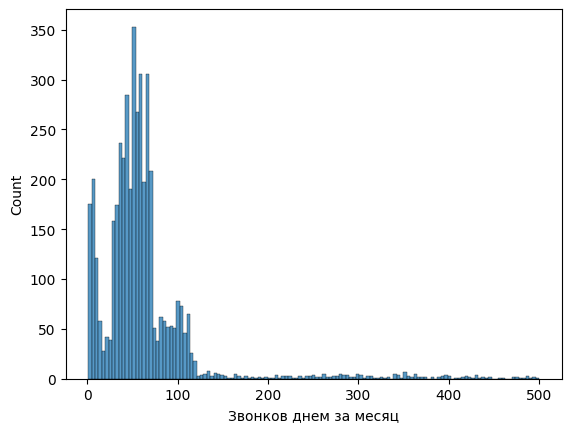

In [ ]:
sns.histplot(data=df,
             x=df['Звонков днем за месяц'])

In [ ]:
# 3. Проверяем гипотезу о равенстве параметров
# клиенты чаще звонят днем или вечером по количеству звонков;
# Н0: Отсутствует статистически значимая разница между количество звонков, совершаемых клиентом днем и вечером.
# Н0: Разница между количество звонков, совершаемых клиентом днем и вечером, статистически незначима.
# H1: Количество звонков, совершаемых клиентами днем, меньше количества звонков, совершаемых клиентами вечером
# используем односторонний критерий -- левосторонний или меньше

# если бы
# клиенты одинаково звонят днем и вечером по количеству звонков;
# Н0: Отсутствует статистически значимая разница между количество звонков, совершаемых клиентом днем и вечером.
# H1: Разница между количество звонков, совершаемых клиентом днем и вечером, статистически значима.
# и тогда используется двусторонний критерий

print(df['Звонков днем за месяц'].dropna().mean(), df['Звонков вечером за месяц'].dropna().mean())
#Важно, гипотезу H1 формулируют отталкиваясь от значений параметром (выборочное среднее, медиана)
#H1: Количество звонков, совершаемых клиентами днем, меньше количества звонков, совершаемых клиентами вечером

# Загрузка
# Профилирование
# Предобработка
# Исследовательский анализ - EDA
# Проверка гипотез
mannwhitneyu(df['Звонков днем за месяц'],
             df['Звонков вечером за месяц'],
             alternative='less',
             nan_policy='omit')

63.89937388193202 70.36377812430385


MannwhitneyuResult(statistic=7786390.5, pvalue=1.0)

In [ ]:
# добавлено
# клиенты больше звонили в 2019 году по сравнению с 2021 годом по количеству звонков.

df['общее_количество_звонков_за_месяц'] = df['Звонков вечером за месяц']
+ df['Звонков днем за месяц'] + df['Звонков ночью за месяц']


In [ ]:
df

,Возраст,Среднемесячный расход,Средняя продолжительность разговоров,Звонков днем за месяц,Звонков вечером за месяц,Звонков ночью за месяц,Звонки в другие города,Звонки в другие страны,Доля звонков на стационарные телефоны,Количество SMS за месяц,Дата подключения тарифа,Год поключения,общее_количество_звонков_за_месяц
0,24,NaN,2.4,12.0,65.0,5.0,0.0,0,5.0,56,2018-06-17 12:14:35,2018,82.0
1,51,287.51,1.7,111.0,109.0,1.0,44.0,0,6.0,1,2021-10-21 15:39:54,2021,221.0
2,41,113.70,2.1,41.0,27.0,0.0,0.0,0,1.0,36,2015-03-26 11:26:15,2015,68.0
3,35,410.23,5.6,47.0,49.0,0.0,0.0,0,11.0,23,2016-01-04 15:53:20,2016,96.0
4,26,537.60,4.8,58.0,77.0,4.0,0.0,0,16.0,29,2017-05-03 13:33:53,2017,139.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4487,40,186.20,3.7,36.0,28.0,2.0,6.0,0,12.0,30,2021-04-10 14:58:23,2021,66.0
4488,40,500.68,6.0,46.0,66.0,0.0,6.0,0,15.0,23,2021-09-22 14:52:43,2021,112.0
4489,60,470.42,3.5,58.0,129.0,2.0,4.0,0,19.0,5,2019-04-04 17:33:38,2019,189.0
4490,38,858.99,9.3,50.0,74.0,0.0,0.0,0,28.0,69,2015-12-30 16:28:26,2015,124.0


Для биноминальных распределений

$$
\begin{multline*}
z = \dfrac{\dfrac{m_1}{n_1}+ \dfrac{1}{2n_1} - \dfrac{m_2}{n_2} - \dfrac{1}{2n_2}}{\sqrt{\dfrac{m_1+m_2}{n_1+n_2} \dfrac{n_1+n_2 - m_1 - m_2}{n_1+n_2}\left(\dfrac{1}{n_1}+\dfrac{1}{n_2}\right)}} = \\
= \dfrac{\dfrac{m_1}{n_1}- \dfrac{m_2}{n_2} + \dfrac{1}{2n_1} - \dfrac{1}{2n_2}}{\sqrt{\dfrac{m_1+m_2}{n_1+n_2} \left( 1-\dfrac{m_1+m_2}{n_1+n_2}\right)\left(\dfrac{1}{n_1}+\dfrac{1}{n_2}\right)}}
\end{multline*}
$$


In [ ]:
#для биноминальных распределений
def test_z_criterion(col, goal, alpha):
    import scipy.stats as st
    import math
    gen_group_shape = df[col].value_counts()
    goal_group_shape = df.groupby(col)[goal].sum()
    p = goal_group_shape / gen_group_shape
    p_combined = goal_group_shape.sum() / gen_group_shape.sum()
    difference = p.iloc[0] - p.iloc[1]
    z_value = difference / math.sqrt(p_combined * (1 - p_combined) * (1/gen_group_shape.iloc[0] + 1/gen_group_shape.iloc[1]))
    distr = st.norm(0, 1)
    p_value = (1 - distr.cdf(abs(z_value))) * 2
    print('Результаты проверки гипотезы H_0 по z-критерию:')
    print('Уровень значимости alpha={:.2f}'.format(alpha))
    print('P-value: {:.2f}'.format(p_value))
    if p_value < alpha:
        print(f"""Отвергаем нулевую гипотезу: разница в долях
по признаку <<{col}>> статистически значима.""")
    else: print(f"""Не получилось отвергнуть нулевую гипотезу: разница в долях по
признаку <<{col}>> статистически незначима.""")
    print('------------------------------------------------------------')